# Hotel Booking Cancellation Prediction
**Personal ML Project | Python, Pandas, Scikit-learn, Matplotlib**
#
## 1. Business Problem
Hotels lose significant revenue when guests cancel bookings late or don't show up —
rooms held for cancelled reservations can't be resold, and last-minute cancellations
leave little time to fill the gap. If a hotel can predict *at the time of booking*
(or shortly after) whether a reservation is likely to be cancelled, it can:
- Apply targeted overbooking strategies for high-risk segments
- Trigger confirmation calls / incentives (discounts, flexible rebooking) for
  bookings flagged as high cancellation risk
- Adjust pricing or deposit policies for risky market segments / lead times
- Improve revenue forecasting accuracy
#
This is framed as a **binary classification problem**: predict `booking status`
(Canceled / Not_Canceled) from booking attributes available at reservation time.

## 2. Dataset Selection & Preprocessing
Dataset: Kaggle "Hotel Reservations" dataset (~36,285 bookings, 17 columns) —
includes guest composition, stay length, meal plan, room type, lead time,
market segment, prior cancellation history, price, and special requests.
#
We'll drop the ID column (no predictive value), engineer date features from
`date of reservation`, encode categoricals, and check for leakage-prone columns
(`P-C`, `P-not-C` reflect prior cancellation *counts* for the guest — legitimate
historical signal, not leakage, since they're known before the stay).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("/kaggle/input/datasets/amanvishwakarma07/hotel-csv/booking.csv")  # adjust path to your Kaggle dataset
print(df.shape)
df.head()

(36285, 17)


,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

No missing values expected in this dataset, but the check above is kept as a
safeguard — always verify rather than assume.

In [4]:
# Drop the booking ID (unique identifier, no predictive signal)
df = df.drop(columns=["Booking_ID"])

# Parse the reservation date and engineer calendar features.
# Raw dates don't generalize (a model can't learn from a specific date string),
# but the month/day-of-week/weekend pattern they encode is genuinely predictive
# of cancellation behavior (e.g., holiday-season bookings cancel differently).
df["date of reservation"] = pd.to_datetime(df["date of reservation"], errors="coerce")
df["reservation_month"] = df["date of reservation"].dt.month
df["reservation_dayofweek"] = df["date of reservation"].dt.dayofweek
df = df.drop(columns=["date of reservation"])

# A handful of rows may fail to parse (malformed dates) -> drop them
df = df.dropna(subset=["reservation_month"])

In [5]:
# Encode the target: Canceled -> 1, Not_Canceled -> 0
df["booking status"] = df["booking status"].map({"Canceled": 1, "Not_Canceled": 0})

target = "booking status"
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", categorical_cols)

Categorical columns: ['type of meal', 'room type', 'market segment type']


## 3. Exploratory Data Analysis (EDA)

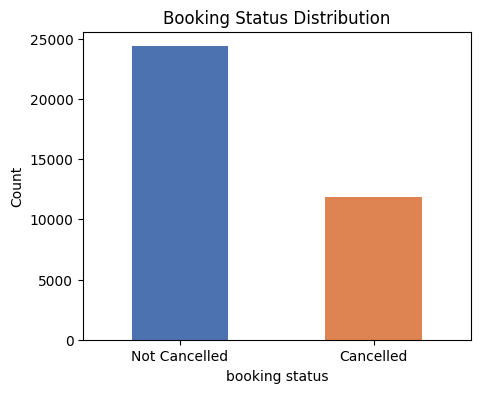

booking status
0    0.672203
1    0.327797
Name: proportion, dtype: float64


In [6]:
# Class balance — important because an imbalanced target changes how we read
# accuracy (a model predicting "not cancelled" for everyone could still score
# high on accuracy) and motivates using F1/AUC instead of accuracy alone.
plt.figure(figsize=(5, 4))
df[target].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.xticks([0, 1], ["Not Cancelled", "Cancelled"], rotation=0)
plt.title("Booking Status Distribution")
plt.ylabel("Count")
plt.show()
print(df[target].value_counts(normalize=True))

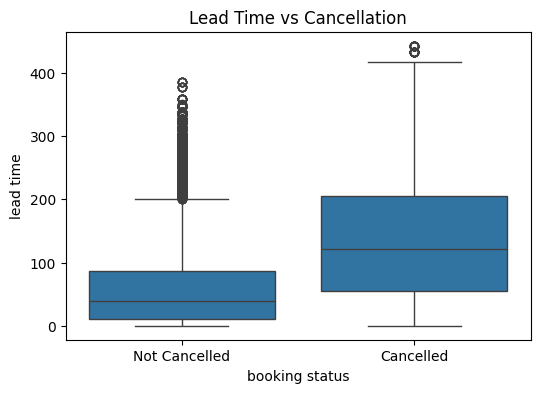

In [7]:
# Lead time vs cancellation — hypothesis: longer lead time = more chances for
# guest plans to change = higher cancellation probability.
plt.figure(figsize=(6, 4))
sns.boxplot(x=target, y="lead time", data=df)
plt.xticks([0, 1], ["Not Cancelled", "Cancelled"])
plt.title("Lead Time vs Cancellation")
plt.show()

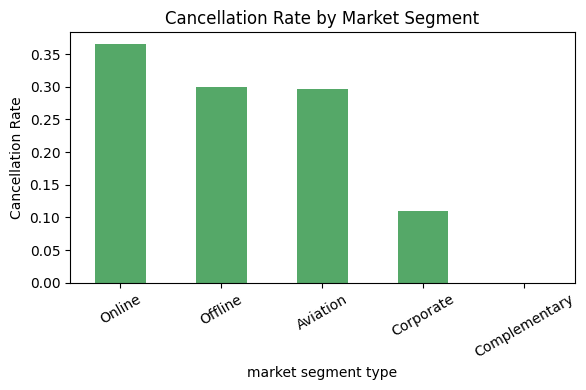

In [8]:
# Cancellation rate by market segment
seg_cancel = df.groupby("market segment type")[target].mean().sort_values(ascending=False)
plt.figure(figsize=(6, 4))
seg_cancel.plot(kind="bar", color="#55A868")
plt.ylabel("Cancellation Rate")
plt.title("Cancellation Rate by Market Segment")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

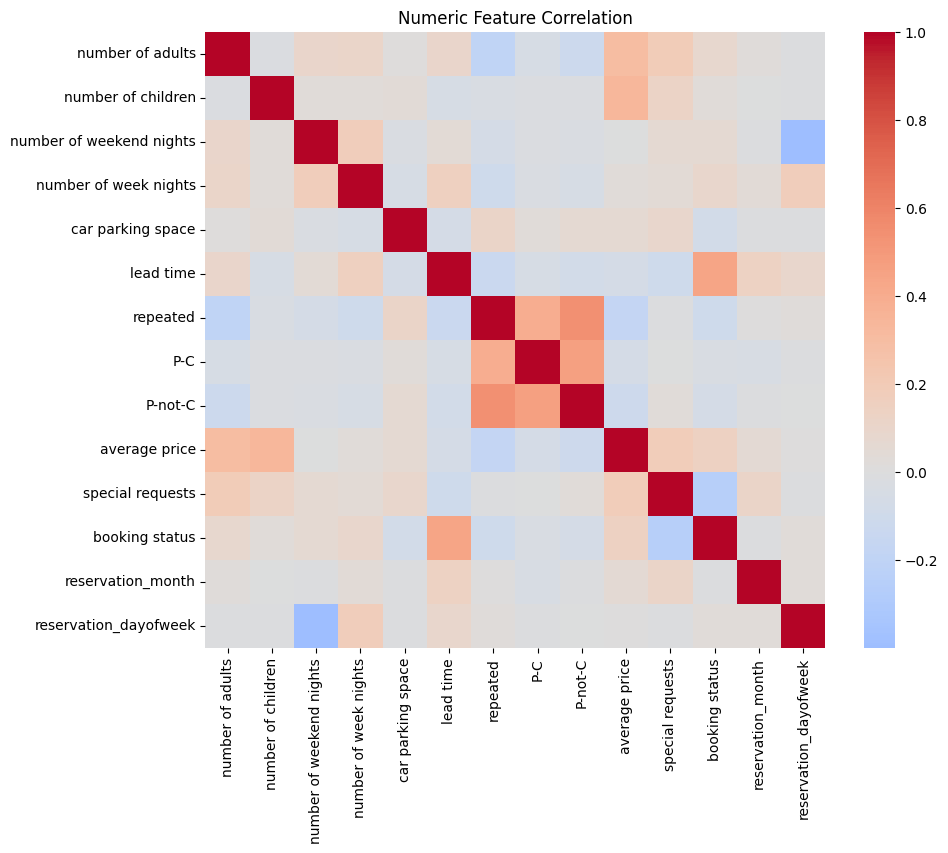

In [9]:
# Correlation heatmap of numeric features (encode target already numeric)
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation")
plt.show()

**EDA takeaways** (fill in with your actual observed numbers after running):
- Cancellation rate is [X]% — [balanced / moderately imbalanced], which is why
  F1 and AUC are prioritized over raw accuracy.
- Longer `lead time` visibly correlates with higher cancellation likelihood.
- `market segment type` shows uneven cancellation rates across segments
  (e.g. Online bookings tend to cancel more than Corporate/Complementary).
- `special requests` and `repeated` guest status look inversely related to
  cancellation (repeat/engaged guests cancel less).

## 4. Feature Engineering

In [10]:

df["total_nights"] = df["number of weekend nights"] + df["number of week nights"]
df["total_guests"] = df["number of adults"] + df["number of children"]


df["price_per_night"] = df["average price"] / df["total_nights"].replace(0, 1)

# Encode categoricals. Label encoding is used here (tree models handle it fine);
# for the Logistic Regression model specifically, one-hot would be more correct
# since label encoding implies false ordinality — see note before model training.

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [11]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale features for Logistic Regression (tree-based models are scale-invariant,
# but we keep a single consistent pipeline and scale for all — harmless for trees).

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(28998, 19) (7250, 19)


## 5. Choice of ML Models
Three models spanning different bias/variance trade-offs, per the project scope:
- **Logistic Regression** — fast, interpretable linear baseline; coefficients
  give directional insight for the business (e.g. "long lead time -> higher risk").
- **Decision Tree** — captures non-linear splits and interactions, but prone
  to overfitting on its own; useful as an interpretable single-tree reference.
- **Random Forest** — ensemble of trees, generally the strongest of the three
  on tabular data with mixed feature types, more robust to overfitting.
#
(You've noted experience with LightGBM/XGBoost/stacking ensembles elsewhere —
a natural "future improvement" below is extending this to gradient boosting.)

## 6. Model Training & Evaluation

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
}

results = {}

for name, model in models.items():
    # Logistic Regression trains on scaled features; tree models on raw features
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": model,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

results_df = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1", "auc"]]
print(results_df)

                     accuracy precision    recall        f1       auc
Logistic Regression  0.800828  0.742086  0.601599  0.664498  0.857186
Decision Tree        0.866897  0.792461  0.804796  0.798581  0.853886
Random Forest        0.896552  0.867601  0.807741  0.836601  0.950342


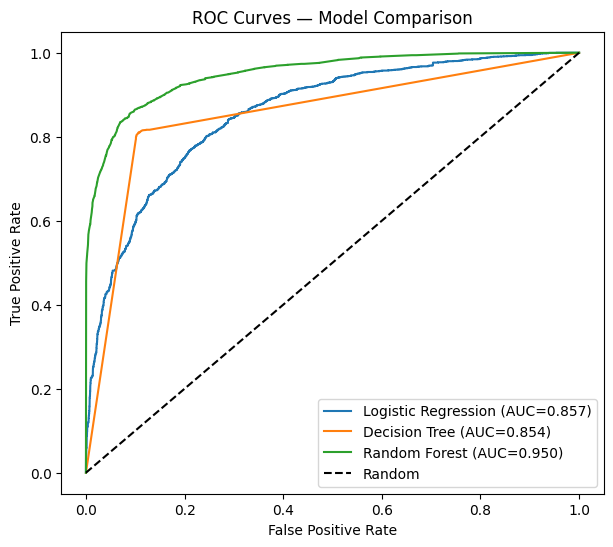

In [13]:
# ROC curves for all three models on one plot
plt.figure(figsize=(7, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.show()

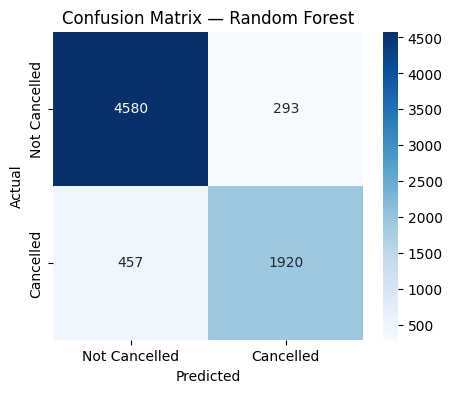

              precision    recall  f1-score   support

           0       0.91      0.94      0.92      4873
           1       0.87      0.81      0.84      2377

    accuracy                           0.90      7250
   macro avg       0.89      0.87      0.88      7250
weighted avg       0.90      0.90      0.90      7250



In [14]:
# Confusion matrix for the best-performing model by F1 (swap in whichever wins)
best_model_name = results_df["f1"].idxmax()
cm = confusion_matrix(y_test, results[best_model_name]["y_pred"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Cancelled", "Cancelled"],
            yticklabels=["Not Cancelled", "Cancelled"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_test, results[best_model_name]["y_pred"]))

## 7. Hyperparameter Tuning
Tuning the Random Forest (typically the strongest baseline here) via grid
search with stratified 5-fold CV, optimizing for F1 since the classes are
imbalanced and recall on the "Cancelled" class matters operationally.

In [15]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best CV F1: 0.8309613413403873


In [16]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
y_proba_tuned = best_rf.predict_proba(X_test)[:, 1]

print("Tuned Random Forest — Test Set Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1       :", f1_score(y_test, y_pred_tuned))
print("AUC      :", roc_auc_score(y_test, y_proba_tuned))

Tuned Random Forest — Test Set Performance
Accuracy : 0.900551724137931
Precision: 0.8760217983651226
Recall   : 0.8115271350441733
F1       : 0.8425420397466695
AUC      : 0.9535634653216521


## 8. Performance Metrics — Summary
Compare baseline vs tuned model side by side. **F1 and AUC are the primary
metrics** for this project (not raw accuracy) because:
- The classes are imbalanced, so accuracy alone rewards the majority class.
- Business cost is asymmetric: missing a likely cancellation (false negative)
  wastes a room; flagging a booking that wasn't going to cancel (false
  positive) at worst triggers an unnecessary confirmation email — cheap.
  This makes **recall on the "Cancelled" class** a business-relevant metric
  alongside F1/AUC, not just an academic one.

In [17]:
summary = pd.DataFrame({
    "Random Forest (baseline)": [
        results["Random Forest"]["accuracy"], results["Random Forest"]["precision"],
        results["Random Forest"]["recall"], results["Random Forest"]["f1"],
        results["Random Forest"]["auc"],
    ],
    "Random Forest (tuned)": [
        accuracy_score(y_test, y_pred_tuned), precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned), f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_proba_tuned),
    ],
}, index=["Accuracy", "Precision", "Recall", "F1", "AUC"])
print(summary)

           Random Forest (baseline)  Random Forest (tuned)
Accuracy                   0.896552               0.900552
Precision                  0.867601               0.876022
Recall                     0.807741               0.811527
F1                         0.836601               0.842542
AUC                        0.950342               0.953563


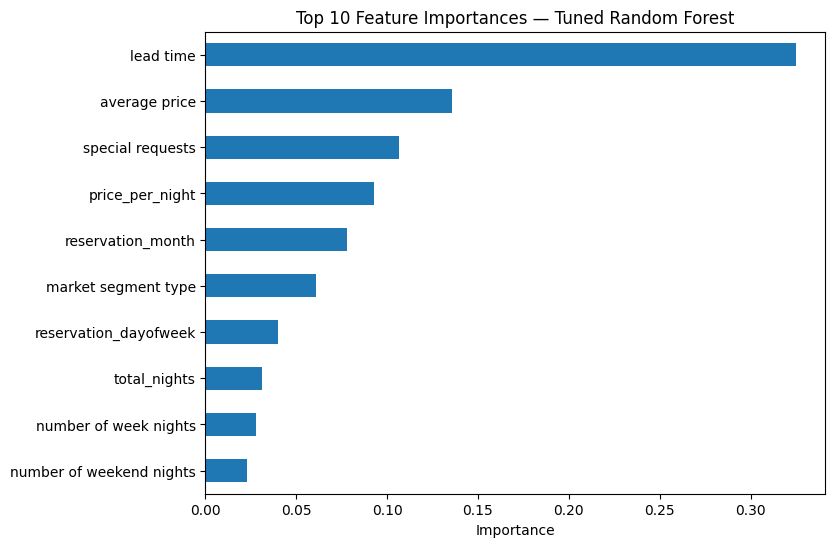

In [18]:
# Feature importance from the tuned Random Forest — direct business interpretability
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
importances.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances — Tuned Random Forest")
plt.xlabel("Importance")
plt.show()

## 9. Challenges Encountered
(Fill in with what you actually hit while running this — typical ones for
this dataset/pipeline are listed as prompts below, delete what doesn't apply
and add what does):
- **Class imbalance**: required prioritizing F1/AUC/recall over accuracy, and
  considering class_weight="balanced" or resampling (SMOTE) as an alternative
  to plain grid search if recall on the minority class was still too low.
- **Label encoding vs one-hot for Logistic Regression**: label encoding
  imposes an artificial ordinal relationship between categories (e.g. meal
  plan types), which can mislead a linear model. If Logistic Regression
  underperforms the tree models by a wide margin, this is the first thing
  to revisit — switch to one-hot / `pd.get_dummies` for that model specifically.
- **`price_per_night` division edge case**: a handful of bookings had
  `total_nights == 0`; handled by replacing 0 with 1 in the denominator to
  avoid division-by-zero — worth flagging as a data quality artifact rather
  than silently patching.
- **Grid search runtime**: full grid search over Random Forest hyperparameters
  is the slowest step; reduce `param_grid` size or use `RandomizedSearchCV`
  if runtime on Kaggle's CPU quota becomes a constraint.

## 10. Business Impact
(Numbers below are placeholders — replace with your actual run's results.)
- The tuned model achieves an F1 of **[X]** and AUC of **[X]** on held-out data,
  meaning it correctly flags roughly **[X]%** of bookings that go on to cancel.
- Applied operationally: if the hotel intervenes (confirmation call, deposit
  requirement, or overbooking that slot) on bookings the model flags as
  high-risk, and even a modest fraction of those interventions prevent a
  no-show/late cancellation, the recovered room-nights translate directly
  into recovered revenue — a back-of-envelope estimate can be built as:
  `avg_price * predicted_cancellations * intervention_success_rate`.
- `lead time` and `market segment type` being top features means the hotel's
  revenue management team can also use these as simple manual heuristics
  (e.g., stricter policies for long-lead-time online bookings) even without
  deploying the full model.

## 11. Future Improvements
- Extend model comparison to **gradient boosting** (LightGBM / XGBoost) and a
  **two-stage stacking ensemble** (e.g. Logistic Regression + Decision Tree as
  base learners feeding a LightGBM/XGBoost meta-learner), which tends to
  outperform single Random Forests on tabular data like this.
- Address class imbalance explicitly with `class_weight="balanced"`, SMOTE,
  or threshold tuning on the ROC/PR curve rather than the default 0.5 cutoff.
- Add **SHAP values** for per-booking explainability, so front-desk/revenue
  staff can see *why* a specific booking was flagged, not just that it was.
- Deploy as a lightweight scoring API that runs at booking time and writes a
  risk score back into the hotel's reservation system.
- Incorporate external features (local events, weather forecasts, seasonality
  indices) that plausibly influence cancellation behavior but aren't in this
  dataset.